# US SP500 Regime Prediction

In [12]:
# dependence
# %pip install yfinance pandas numpy matplotlib hmmlearn scikit-learn -q

In [13]:
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt
from scipy.stats import norm

import adapter

In [14]:
# get data
adapter = adapter.YFinanceAdapter()
data= adapter.get_data(tickers="^GSPC", start_date="2019-01-01",end_date="2026-01-01")

Loading data from cache...


In [15]:
data['return'] = data['Adj Close'].pct_change()
data = data.dropna()

## Train model

In [16]:
train = data.loc["2019-01-01":"2023-12-31"].copy()
test  = data.loc["2024-01-01":"2025-12-31"].copy()

X_train = train['return'].values.reshape(-1, 1)
X_test  = test['return'].values.reshape(-1, 1)

### 1. 2 states test

In [17]:
# define model: bear, bull
model = GaussianHMM(
    n_components=2, 
    covariance_type="full", 
    n_iter=1000,
    random_state=42
)

model.fit(X_train)

e:\Code\Anaconda\envs\hwenv\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


GaussianHMM(covariance_type='full', n_components=2, n_iter=1000,
            random_state=42)

Adapt filtering

In [18]:
test_states = []

_, current_prob = model.score_samples(X_train[-10:])  
current_prob = current_prob[-1]

means = model.means_.flatten()
vars_ = model.covars_.flatten()

for t in range(len(X_test)):
    
    pred_prob = np.dot(current_prob, model.transmat_)

    obs = X_test[t][0]
    
    likelihood = np.array([
        norm.pdf(obs, means[i], np.sqrt(vars_[i]))
        for i in range(model.n_components)
    ])

    current_prob = pred_prob * likelihood
    current_prob /= current_prob.sum()

    state = np.argmax(current_prob)
    test_states.append(state)

test['state'] = test_states

In [19]:
train_states = model.predict(X_train)

state_means = []
for i in range(model.n_components):
    state_means.append(X_train[train_states == i].mean())

state_means = np.array(state_means)
bull_state = np.argmax(state_means)

test['signal'] = test['state'].apply(lambda s: 1 if s == bull_state else 0)
test['strategy_return'] = test['signal'].shift(1) * test['return']
test['strategy_return'] = test['strategy_return'].fillna(0)
test['wealth_market']   = (1 + test['return']).cumprod()
test['wealth_strategy'] = (1 + test['strategy_return']).cumprod()

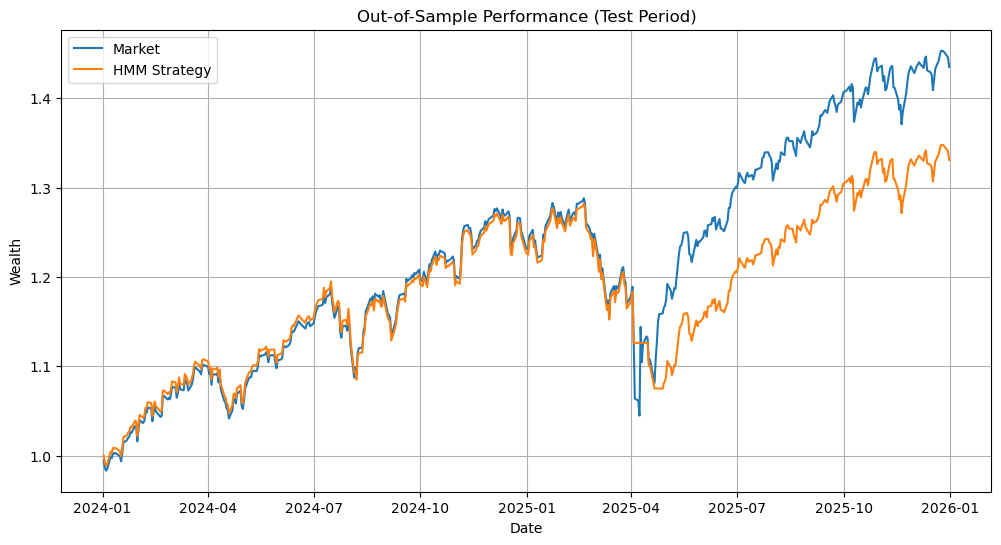

In [20]:

plt.figure(figsize=(12,6))

plt.plot(test.index, test['wealth_market'], label='Market')
plt.plot(test.index, test['wealth_strategy'], label='HMM Strategy')

plt.legend()
plt.title('Out-of-Sample Performance (Test Period)')
plt.xlabel('Date')
plt.ylabel('Wealth')
plt.grid(True)

plt.show()

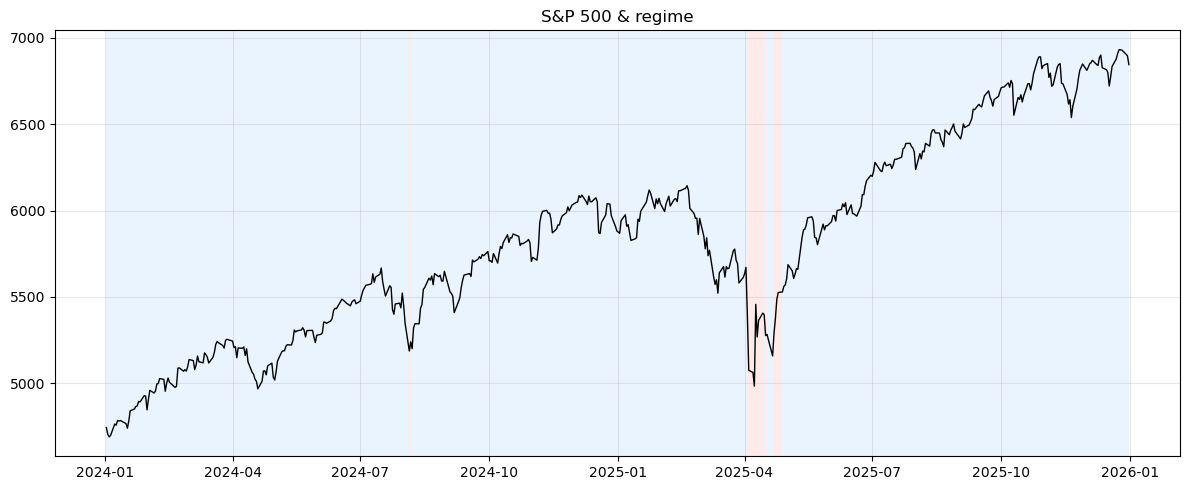

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = {0: "#ddeeff", 1: "#ffdddd",}  
for i in range(len(test) - 1):
    s = int(test["state"].iloc[i])
    ax.axvspan(test.index[i], test.index[i + 1], color=colors.get(s, "#eee"), alpha=0.6, lw=0)
ax.plot(test.index, test["Adj Close"], color="k", lw=1, zorder=3)
ax.set_title("S&P 500 & regime")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2. 3 state test